In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s4e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s4e8/train.csv
/kaggle/input/competitions/playground-series-s4e8/test.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import xgboost as xgb

In [3]:
data=pd.read_csv(r"/kaggle/input/competitions/playground-series-s4e8/train.csv")

In [4]:
data.head()

,id,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,0,e,8.80,f,s,u,f,a,c,w,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
1,1,p,4.51,x,h,o,f,a,c,n,...,NaN,y,o,NaN,NaN,t,z,NaN,d,w
2,2,e,6.94,f,s,b,f,x,c,w,...,NaN,s,n,NaN,NaN,f,f,NaN,l,w
3,3,e,3.88,f,y,g,f,s,NaN,g,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,u
4,4,e,5.85,x,l,w,f,d,NaN,w,...,NaN,NaN,w,NaN,NaN,f,f,NaN,g,a


In [5]:
data.shape

(3116945, 22)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3116945 entries, 0 to 3116944
Data columns (total 22 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   class                 object 
 2   cap-diameter          float64
 3   cap-shape             object 
 4   cap-surface           object 
 5   cap-color             object 
 6   does-bruise-or-bleed  object 
 7   gill-attachment       object 
 8   gill-spacing          object 
 9   gill-color            object 
 10  stem-height           float64
 11  stem-width            float64
 12  stem-root             object 
 13  stem-surface          object 
 14  stem-color            object 
 15  veil-type             object 
 16  veil-color            object 
 17  has-ring              object 
 18  ring-type             object 
 19  spore-print-color     object 
 20  habitat               object 
 21  season                object 
dtypes: float64(3), int64(1), object(18)
memory

In [7]:
data.isnull().sum()

id                            0
class                         0
cap-diameter                  4
cap-shape                    40
cap-surface              671023
cap-color                    12
does-bruise-or-bleed          8
gill-attachment          523936
gill-spacing            1258435
gill-color                   57
stem-height                   0
stem-width                    0
stem-root               2757023
stem-surface            1980861
stem-color                   38
veil-type               2957493
veil-color              2740947
has-ring                     24
ring-type                128880
spore-print-color       2849682
habitat                      45
season                        0
dtype: int64

In [8]:
(data.isnull().sum())/(len(data))* 100

id                       0.000000
class                    0.000000
cap-diameter             0.000128
cap-shape                0.001283
cap-surface             21.528227
cap-color                0.000385
does-bruise-or-bleed     0.000257
gill-attachment         16.809280
gill-spacing            40.373988
gill-color               0.001829
stem-height              0.000000
stem-width               0.000000
stem-root               88.452732
stem-surface            63.551362
stem-color               0.001219
veil-type               94.884350
veil-color              87.936970
has-ring                 0.000770
ring-type                4.134818
spore-print-color       91.425482
habitat                  0.001444
season                   0.000000
dtype: float64

In [9]:
data.drop(['id','spore-print-color','veil-color','veil-type','stem-root','stem-surface'],axis=1,inplace=True)

In [10]:
data.duplicated().sum()

np.int64(477)

In [11]:
data.drop_duplicates(inplace= True)

In [12]:
data.columns

Index(['class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-height', 'stem-width', 'stem-color', 'has-ring', 'ring-type',
       'habitat', 'season'],
      dtype='object')

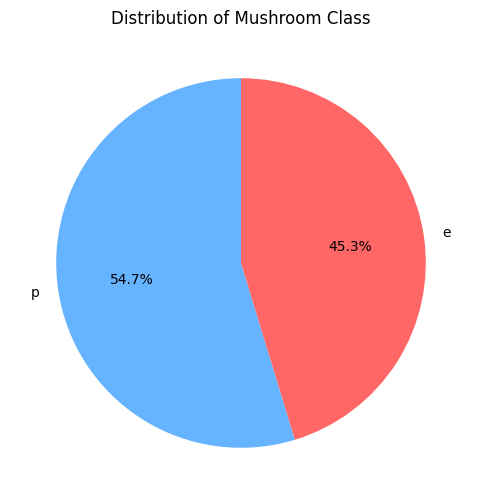

In [13]:
import matplotlib.pyplot as plt
class_counts = data['class'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(class_counts,labels=class_counts.index,autopct='%1.1f%%',startangle=90,colors=['#66b3ff','#ff6666'])
plt.title("Distribution of Mushroom Class")
plt.show()

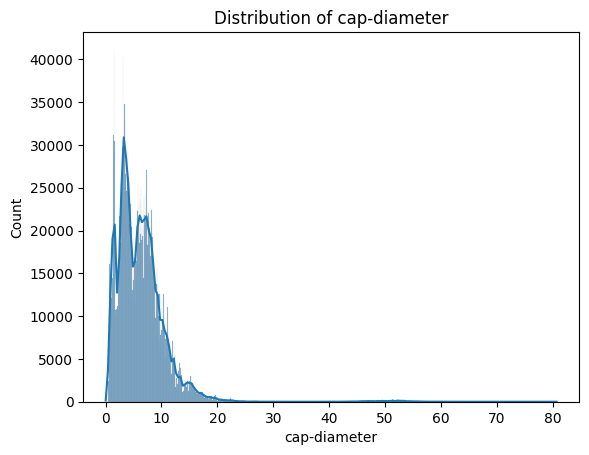

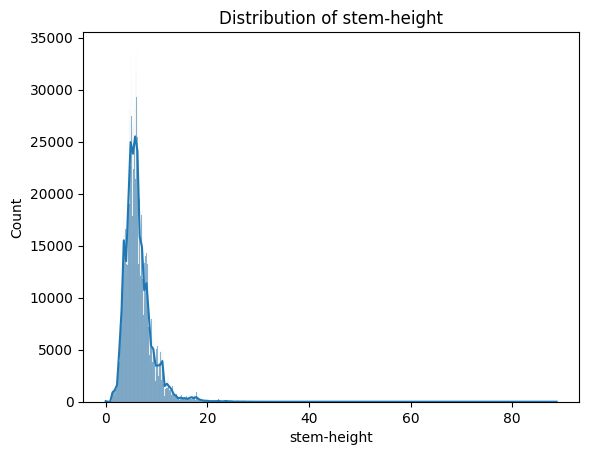

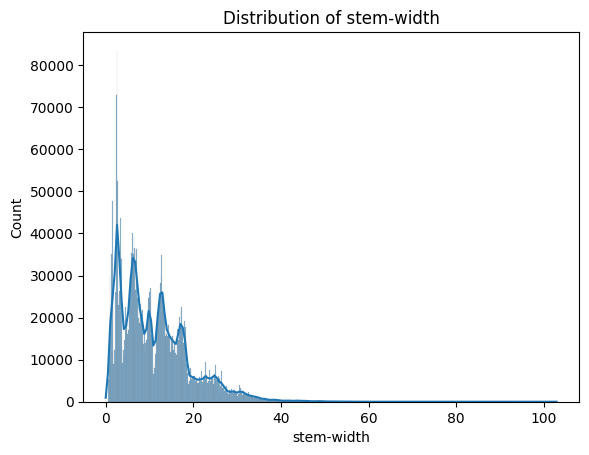

In [14]:
# Numerical Features Distribution
num_cols_all = data.select_dtypes(include=['int64','float64']).columns

for col in num_cols_all:

    plt.figure()
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


The distributions of stem-width and stem-height show a similar pattern to cap-diameter.

* Both features are right-skewed (positively skewed).

* Most values are concentrated in the lower range.

* There is a long tail extending toward higher values.

**This means that:**

* Most mushrooms have relatively small stem width and height,

* while only a small number of mushrooms have much larger stems.

Such a pattern is common in biological datasets, where smaller measurements are more frequent and larger ones occur less often.

              cap-diameter  stem-height  stem-width
cap-diameter      1.000000     0.364017    0.746296
stem-height       0.364017     1.000000    0.356163
stem-width        0.746296     0.356163    1.000000


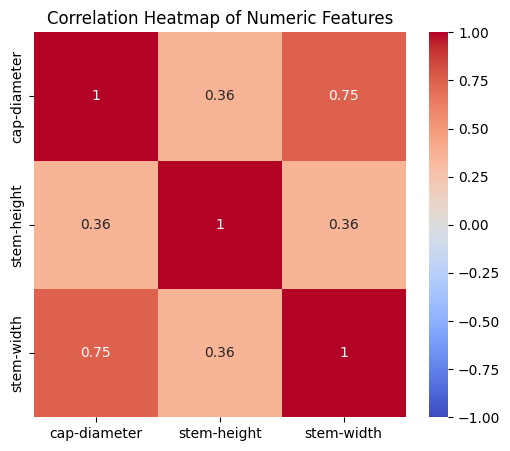

In [15]:
corr_matrix = data[num_cols_all].corr()
print(corr_matrix)
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True,cmap='coolwarm',vmin=-1, vmax=1) 
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [16]:
data['ring-type'].unique()

array(['f', 'z', 'e', nan, 'p', 'l', 'g', 'r', 'm', 'y', 'h', 'o', 't',
       'ring-type', 'a', 'd', 's', 'x', '4', 'b', '15', 'u', 'n', 'w',
       'does f', '3.12', 'i', 'season', 'k', 'c', 'does-bruise-or-bleed',
       '11', '23.6', '1', '14', '2', 'spore-print-color', 'class', 'sp',
       '2.87', '8.25'], dtype=object)

In [17]:
data['ring-type'].value_counts()

ring-type
f                       2476787
e                        120004
z                        113773
l                         73443
r                         67864
p                         67677
g                         63652
m                          3992
t                            98
d                            37
n                            34
x                            32
b                            29
y                            25
s                            18
k                            18
a                            16
h                            15
w                            14
u                            13
c                            11
o                             9
ring-type                     7
i                             4
does f                        3
season                        3
4                             1
15                            1
3.12                          1
does-bruise-or-bleed          1
11                            

In [18]:
data['cap-shape'].unique()

array(['f', 'x', 'p', 'b', 'o', 'c', 's', 'd', 'e', 'n', nan, 'w', 'k',
       'l', '19.29', '5 f', 't', 'g', 'z', 'a', '2.85', '7 x', 'r', 'u',
       '3.55', 'is s', 'y', '4.22', '3.6', '21.56', 'i', '6 x', '24.16',
       '8', 'm', 'ring-type', '10.13', 'is p', '7.43', 'h', '0.82',
       '10.46', '2.77', '2.94', '12.62', '5.15', '19.04', '4.97', '49.21',
       'b f', '9.13', '1.66', '3.37', '7.21', '3.25', '11.12', '3 x',
       '4.3', '7.41', '6.21', '8.29', '54.78', '20.25', '3.52', '3.04',
       '2.63', '3.91', '6.44', '8.3', '7.6', '17.44', '4.33', '2.82',
       '6.53', '19.06'], dtype=object)

In [19]:
data['cap-shape'].value_counts()

cap-shape
x        1435642
f         676198
s         365141
b         318616
o         108823
          ...   
17.44          1
4.33           1
2.82           1
6.53           1
19.06          1
Name: count, Length: 74, dtype: int64

In [20]:
cat_cols_all = data.select_dtypes(include=['object']).columns
# use regular expression to extract the categories
for col in cat_cols_all:

    data[col] = data[col].str.extract(r'^([A-Za-z])')

In [21]:
def remove_small_categories(data, cols, min_count=100000):

    for col in cols:
        counts = data[col].value_counts()
        valid = counts[counts >= min_count].index
        data[col] = data[col].where(data[col].isin(valid))

    return data
data = remove_small_categories(data,cat_cols_all)

In [22]:
data['cap-shape'].unique()

array(['f', 'x', 'p', 'b', 'o', 'c', 's', nan], dtype=object)

In [23]:
data['cap-shape'].value_counts(dropna=False)

cap-shape
x      1435642
f       676198
s       365141
b       318617
o       108823
p       106962
c       104519
NaN        566
Name: count, dtype: int64

In [24]:
cat_cols_all

Index(['class', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-color', 'has-ring', 'ring-type', 'habitat', 'season'],
      dtype='object')

In [25]:

num_cols_all

Index(['cap-diameter', 'stem-height', 'stem-width'], dtype='object')

In [26]:
for col in cat_cols_all:
    if data[col].isnull().sum() > 0:
        data[col].fillna(data[col].mode()[0], inplace=True)

/tmp/ipykernel_16/3696107377.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [27]:
data.dropna(subset=num_cols_all, inplace=True)

In [28]:
data

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,e,8.80,f,s,n,f,a,c,w,4.51,15.39,w,f,f,d,a
1,p,4.51,x,h,o,f,a,c,n,4.79,6.48,o,t,z,d,w
2,e,6.94,f,s,n,f,x,c,w,6.85,9.93,n,f,f,l,w
3,e,3.88,f,y,g,f,s,c,g,4.16,6.53,w,f,f,d,u
4,e,5.85,x,t,w,f,d,c,w,3.37,8.36,w,f,f,g,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3116940,e,9.29,f,t,n,t,a,c,w,12.14,18.81,w,t,f,d,u
3116941,e,10.88,s,t,w,t,d,c,p,6.65,26.97,w,f,f,d,u
3116942,p,7.82,x,e,e,f,a,c,w,9.51,11.06,y,t,z,d,a
3116943,e,9.45,p,i,n,t,e,c,p,9.13,17.77,w,t,f,d,u


In [29]:

data['cap-shape'].value_counts()

cap-shape
x    1436206
f     676197
s     365140
b     318617
o     108823
p     106962
c     104519
Name: count, dtype: int64

In [30]:
data.isnull().sum()

class                   0
cap-diameter            0
cap-shape               0
cap-surface             0
cap-color               0
does-bruise-or-bleed    0
gill-attachment         0
gill-spacing            0
gill-color              0
stem-height             0
stem-width              0
stem-color              0
has-ring                0
ring-type               0
habitat                 0
season                  0
dtype: int64

In [31]:
import pandas as pd
import plotly.express as px

ct = pd.crosstab(data['ring-type'], data['class'], normalize='index') * 100
ct = ct.reset_index().melt(id_vars='ring-type', value_name='Percentage', var_name='Class')
fig = px.bar(
    ct,
    x='ring-type',
    y='Percentage',
    color='Class',
    
    barmode='stack', 
    title='Relationship between Ring Type and Mushroom Class'
)

fig.update_layout(
    xaxis_title='Ring-Type',
    yaxis_title='Percentage (%)',
    template='plotly_white'
)

fig.show()

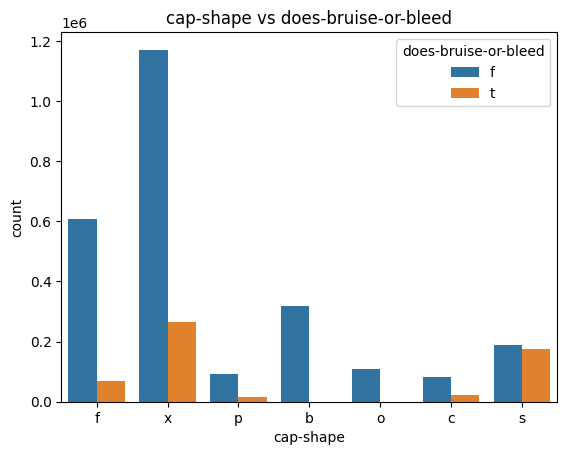

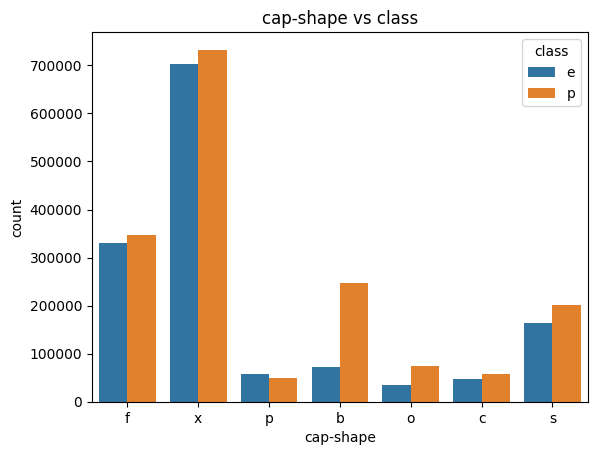

In [32]:
sns.countplot(data=data, x='cap-shape', hue='does-bruise-or-bleed')
plt.title("cap-shape vs does-bruise-or-bleed")
plt.show()

sns.countplot(data=data, x='cap-shape', hue='class')
plt.title("cap-shape vs class")
plt.show()

In [33]:

pd.crosstab(data['cap-shape'], data['does-bruise-or-bleed'], normalize='index')

does-bruise-or-bleed,f,t
cap-shape,,
b,0.999667,0.000333
c,0.779255,0.220745
f,0.899488,0.100512
o,0.999173,0.000827
p,0.856734,0.143266
s,0.520871,0.479129
x,0.815091,0.184909


In [34]:
import plotly.express as px
import pandas as pd
ct = pd.crosstab(
    [data['cap-shape'], data['does-bruise-or-bleed']],
    data['class']
).reset_index()
ct.columns.name = None 
ct = ct.rename(columns={'e': 'edible', 'p': 'poisonous'})
"""
fig = px.bar(ct,x='cap-shape',y=['edible', 'poisonous'],  color_discrete_sequence=['green','red'],
             labels={'value': 'Count', 'cap-shape':'Cap Shape'},title='Cap Shape vs Does-Bruise-or-Bleed vs Class')
"""
fig = px.bar(ct,x='cap-shape',y=['edible','poisonous'],color_discrete_sequence=['green','red'],
             facet_col='does-bruise-or-bleed',
    labels={'value': 'Count', 'cap-shape':'Cap Shape', 'does-bruise-or-bleed':'Bruise/Bleed'},
    title='Cap Shape vs Does-Bruise-or-Bleed vs Class')

fig.update_layout(barmode='stack', showlegend=True)
fig.show()

In [35]:
data

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,e,8.80,f,s,n,f,a,c,w,4.51,15.39,w,f,f,d,a
1,p,4.51,x,h,o,f,a,c,n,4.79,6.48,o,t,z,d,w
2,e,6.94,f,s,n,f,x,c,w,6.85,9.93,n,f,f,l,w
3,e,3.88,f,y,g,f,s,c,g,4.16,6.53,w,f,f,d,u
4,e,5.85,x,t,w,f,d,c,w,3.37,8.36,w,f,f,g,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3116940,e,9.29,f,t,n,t,a,c,w,12.14,18.81,w,t,f,d,u
3116941,e,10.88,s,t,w,t,d,c,p,6.65,26.97,w,f,f,d,u
3116942,p,7.82,x,e,e,f,a,c,w,9.51,11.06,y,t,z,d,a
3116943,e,9.45,p,i,n,t,e,c,p,9.13,17.77,w,t,f,d,u


In [36]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
cap-diameter,3116464.0,6.310281,4.657881,0.03,3.32,5.75,8.24,80.67
stem-height,3116464.0,6.348515,2.699794,0.00,4.67,5.88,7.41,88.72
stem-width,3116464.0,11.154638,8.095371,0.00,4.97,9.65,15.63,102.90


In [37]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [38]:
X = data.drop('class',axis=1)
y = data['class']
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['int64','float64']).columns

In [39]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])

In [41]:
param_grid = {'model__n_estimators': [100,200],'model__max_depth': [4,6,8],'model__learning_rate': [0.01,0.1,0.2]}

In [42]:
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(random_state=42))
])

In [43]:
target_encoder = LabelEncoder()
y_train_enc = target_encoder.fit_transform(y_train)  # 'e'/'p' → 0/1
y_test_enc = target_encoder.transform(y_test)

In [44]:
grid = GridSearchCV(pipeline,param_grid,cv=5,scoring='accuracy',n_jobs=-1)
grid.fit(X_train,y_train_enc)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['cap-diameter', 'stem-height', 'stem-width'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed',
       'gill-attachment', 'gill-spacing', 'gill-color', 'stem-...
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.1, 0.2],
                         'model__max_depth': [4, 6, 8],
                         'model__n_estimators': [100, 200]},
             scoring='accuracy')

In [45]:
print("Best Parameters:",grid.best_params_)

Best Parameters: {'model__learning_rate': 0.2, 'model__max_depth': 8, 'model__n_estimators': 200}


In [46]:
best_model = grid.best_estimator_

In [47]:
y_pred_train = best_model.predict(X_train)

In [48]:
y_pred_test = best_model.predict(X_test)

train Accuracy: 0.9912809831335275


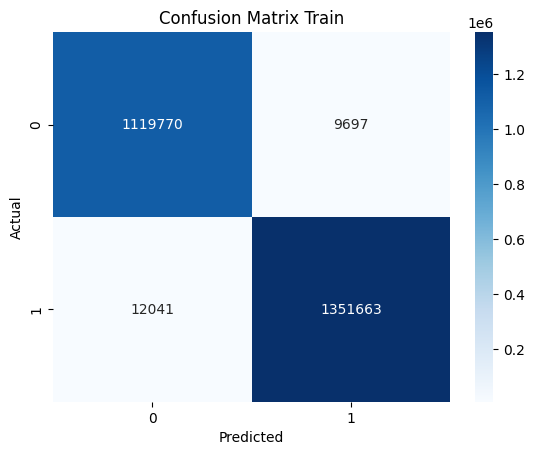

In [49]:
accuracy_train = accuracy_score(y_train_enc,y_pred_train )
print("train Accuracy:",accuracy_train)
cm = confusion_matrix(y_train_enc,y_pred_train)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix Train")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Test Accuracy: 0.9900865243152097


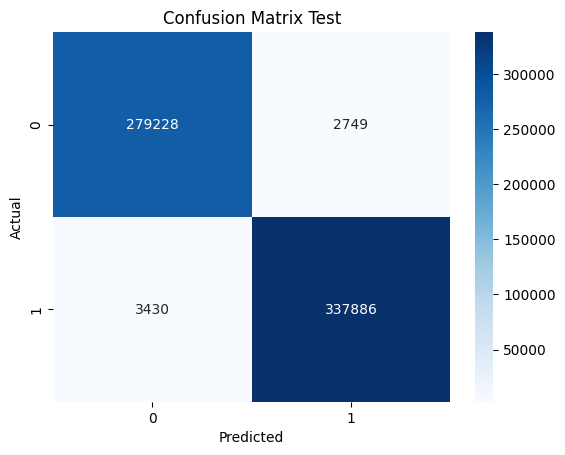

In [50]:
accuracy_test = accuracy_score(y_test_enc,y_pred_test)

print("Test Accuracy:",accuracy_test)
cm = confusion_matrix(y_test_enc,y_pred_test)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix Test")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Test Data****

In [51]:

test_data=pd.read_csv(r"/kaggle/input/competitions/playground-series-s4e8/test.csv")

In [52]:
test_data.head()

,id,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,3116945,8.64,x,NaN,n,t,NaN,NaN,w,11.13,...,b,NaN,w,u,w,t,g,NaN,d,a
1,3116946,6.90,o,t,o,f,NaN,c,y,1.27,...,NaN,NaN,n,NaN,NaN,f,f,NaN,d,a
2,3116947,2.00,b,g,n,f,NaN,c,n,6.18,...,NaN,NaN,n,NaN,NaN,f,f,NaN,d,s
3,3116948,3.47,x,t,n,f,s,c,n,4.98,...,NaN,NaN,w,NaN,n,t,z,NaN,d,u
4,3116949,6.17,x,h,y,f,p,NaN,y,6.73,...,NaN,NaN,y,NaN,y,t,NaN,NaN,d,u


In [53]:
test_ids = test_data['id']

In [54]:
test_data.drop(['id','spore-print-color','veil-color','veil-type','stem-root','stem-surface'], axis=1, inplace=True)

In [55]:
for col in test_data.select_dtypes(include=['object']).columns:
    test_data[col] = test_data[col].str.extract(r'^([A-Za-z])')

In [56]:
cat_test_cols = test_data.select_dtypes(include=['object']).columns
num_test_cols = test_data.select_dtypes(include=['int64','float64']).columns

In [57]:

for col in cat_test_cols:
    if test_data[col].isnull().sum() > 0:
        test_data[col] = test_data[col].fillna(test_data[col].mode()[0])

In [58]:
for col in num_test_cols:
    test_data[col] = test_data[col].fillna(test_data[col].median())

In [59]:
test_data.shape

(2077964, 15)

In [60]:
y_test_pred = best_model.predict(test_data)

In [61]:
y_test_labels = target_encoder.inverse_transform(y_test_pred)

In [62]:
submission = pd.DataFrame({
    'id': test_ids,
    'class': y_test_labels
})

In [63]:
submission.to_csv("submission.csv", index=False)

In [64]:
submission.shape

(2077964, 2)

In [65]:
submission.to_csv("/kaggle/working/submission.csv", index=False)